In [1]:
!pip install pandas numpy sqlalchemy scikit-learn psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 21.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

In [3]:
engine = create_engine("sqlite:///fraud_db.db")

Generating Banking Data


In [4]:
np.random.seed(42)

n = 50000

df = pd.DataFrame({
    "transaction_id": range(n),
    "customer_id": np.random.randint(1, 1000, n),
    "merchant_id": np.random.randint(1, 300, n),
    "amount": np.random.exponential(200, n),
    "is_international": np.random.randint(0, 2, n),
})

df["transaction_time"] = pd.date_range("2024-01-01", periods=n, freq="min")

# Fraud logic (realistic pattern)
df["is_fraud"] = np.where(
    (df["amount"] > 2500) & (df["is_international"] == 1),
    1, 0
)

Loading data to SQL

In [6]:
df.to_sql("transactions", engine, if_exists="replace", index=False)

50000

View high-risk transactions

In [7]:
query = """
SELECT *
FROM transactions
WHERE amount > 3000;
"""

pd.read_sql(query, engine)

,transaction_id,customer_id,merchant_id,amount,is_international,transaction_time,is_fraud


2. Fraud rate per customer

In [8]:
query = """
SELECT
    customer_id,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_cases
FROM transactions
GROUP BY customer_id
ORDER BY fraud_cases DESC;
"""

pd.read_sql(query, engine)

,customer_id,total_transactions,fraud_cases
0,999,51,0
1,998,53,0
2,997,48,0
3,996,51,0
4,995,41,0
...,...,...,...
994,5,44,0
995,4,41,0
996,3,41,0
997,2,38,0


3. High-value + international fraud pattern

In [9]:
query = """
SELECT *
FROM transactions
WHERE amount > 2000 AND is_international = 1;
"""

pd.read_sql(query, engine)

,transaction_id,customer_id,merchant_id,amount,is_international,transaction_time,is_fraud


SQL FEATURE ENGINEERING (ADVANCED)

In [10]:
query = """
SELECT
    customer_id,
    AVG(amount) AS avg_amount,
    COUNT(*) AS total_transactions,
    SUM(is_international) AS international_count,
    SUM(is_fraud) AS fraud_cases
FROM transactions
GROUP BY customer_id;
"""

features = pd.read_sql(query, engine)
features.head()

,customer_id,avg_amount,total_transactions,international_count,fraud_cases
0,1,184.142501,53,31,0
1,2,180.551644,38,14,0
2,3,191.653973,41,27,0
3,4,178.707995,41,19,0
4,5,209.207513,44,24,0


Prepare ML Dataset

In [11]:
X = features[["avg_amount", "total_transactions", "international_count"]]
y = (features["fraud_cases"] > 0).astype(int)

Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Fraud Detection Model

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Evaluate Model

In [14]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Fraud Probability Score

In [18]:
proba_output = model.predict_proba(X)
if proba_output.shape[1] == 1:
    # Model trained on a single class (likely non-fraud), so fraud score is 0
    features["fraud_score"] = 1 - proba_output[:, 0] # This will be 0 if only non-fraud class prob is 1
else:
    # Binary classification, output is [prob_class_0, prob_class_1]
    features["fraud_score"] = proba_output[:, 1]
features.head()

,customer_id,avg_amount,total_transactions,international_count,fraud_cases,fraud_score
0,1,184.142501,53,31,0,0.0
1,2,180.551644,38,14,0,0.0
2,3,191.653973,41,27,0,0.0
3,4,178.707995,41,19,0,0.0
4,5,209.207513,44,24,0,0.0


Anomaly Detection (BONUS)

In [19]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02, random_state=42)

features["anomaly"] = iso.fit_predict(X)
features.head()

,customer_id,avg_amount,total_transactions,international_count,fraud_cases,fraud_score,anomaly
0,1,184.142501,53,31,0,0.0,1
1,2,180.551644,38,14,0,0.0,1
2,3,191.653973,41,27,0,0.0,1
3,4,178.707995,41,19,0,0.0,1
4,5,209.207513,44,24,0,0.0,1


Visualization

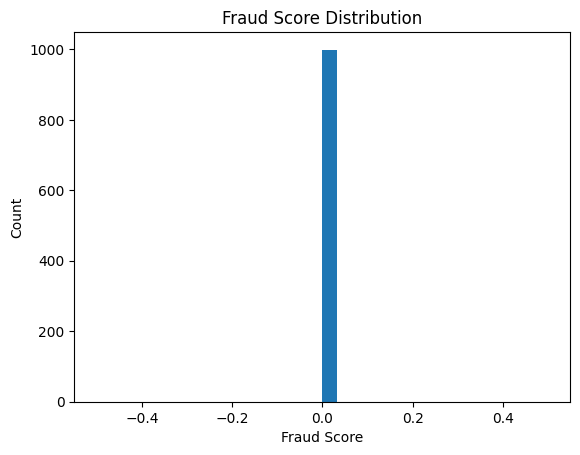

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(features["fraud_score"], bins=30)
plt.title("Fraud Score Distribution")
plt.xlabel("Fraud Score")
plt.ylabel("Count")
plt.show()

Final Insight Table

In [21]:
features.sort_values("fraud_score", ascending=False).head(10)

,customer_id,avg_amount,total_transactions,international_count,fraud_cases,fraud_score,anomaly
998,999,225.807107,51,28,0,0.0,1
0,1,184.142501,53,31,0,0.0,1
1,2,180.551644,38,14,0,0.0,1
2,3,191.653973,41,27,0,0.0,1
3,4,178.707995,41,19,0,0.0,1
4,5,209.207513,44,24,0,0.0,1
5,6,207.815175,41,21,0,0.0,1
982,983,197.051643,53,27,0,0.0,1
981,982,219.678490,59,30,0,0.0,1
980,981,187.324504,55,23,0,0.0,1
